### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [2]:
df = pd.read_csv("Credit_Card.csv",sep=';')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [3]:
print(df["LIMIT_BAL_LOG"].head(20))

0        990.353.755.128.617
1     11.695.255.355.062.700
2     11.407.576.060.361.700
3     10.819.798.284.210.200
4     10.819.798.284.210.200
5     10.819.798.284.210.200
6                        NaN
7      1.151.293.546.492.020
8     11.849.404.844.423.000
9        990.353.755.128.617
10    12.206.077.645.517.600
11    12.468.440.756.144.100
12    13.353.476.685.668.000
13    11.156.264.806.643.700
14    12.429.220.196.836.300
15    10.819.798.284.210.200
16       990.353.755.128.617
17    12.676.079.399.771.000
18    12.793.862.088.206.200
19    12.100.717.685.412.400
Name: LIMIT_BAL_LOG, dtype: str


In [4]:
df.shape

(34788, 30)

### Basic Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   34788 non-null

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,34788.0,15006.206939,8670.802495,1.0,7477.75,15004.5,22526.25,30000.0
LIMIT_BAL,33079.0,184668.994831,235931.930924,10000.0,60000.00,140000.0,240000.00,5600000.0
SEX,33021.0,1.604252,0.489018,1.0,1.00,2.0,2.00,2.0
EDUCATION,33054.0,1.851243,0.790827,0.0,1.00,2.0,2.00,6.0
MARRIAGE,33055.0,1.550870,0.521464,0.0,1.00,2.0,2.00,3.0
AGE,33033.0,35.518300,9.236783,21.0,28.00,34.0,41.00,79.0
PAY_0,34788.0,-0.045792,1.103259,-2.0,-1.00,0.0,0.00,8.0
PAY_2,34788.0,-0.156922,1.177451,-2.0,-1.00,0.0,0.00,8.0
PAY_3,34788.0,-0.185552,1.180412,-2.0,-1.00,0.0,0.00,8.0
PAY_4,34788.0,-0.239077,1.151733,-2.0,-1.00,0.0,0.00,8.0


In [7]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'risk_leak', 'BILL_AMT_SUM', 'LIMIT_BAL_LOG', 'CITY', 'RISK_RATING']


In [8]:
print(df.dtypes)

ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
risk_leak                      object
BILL_AMT_SUM

### Missing Values

In [9]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_df = missing_df[missing_df["Missing Count"] > 0]

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
SEX,1767,5.079338
AGE,1755,5.044843
PAY_AMT2,1744,5.013223
EDUCATION,1734,4.984477
MARRIAGE,1733,4.981603
PAY_AMT1,1725,4.958606
LIMIT_BAL,1709,4.912614
LIMIT_BAL_LOG,1709,4.912614


### Duplicate

In [10]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 2858


### Validation of Engineered Features

In [11]:
df[
    [
        "LIMIT_BAL",
        "LIMIT_BAL_LOG",
        "BILL_AMT_SUM",
        "risk_leak"
    ]
].head(10)

,LIMIT_BAL,LIMIT_BAL_LOG,BILL_AMT_SUM,risk_leak
0,20000.0,990.353.755.128.617,7704.0,1.075.675.276.433.290
1,120000.0,11.695.255.355.062.700,17077.0,10.940.840.854.872.400
2,90000.0,11.407.576.060.361.700,101653.0,0.0703022492301175
3,50000.0,10.819.798.284.210.200,231334.0,0.058442435467177846
4,50000.0,10.819.798.284.210.200,109339.0,0.12943102887089503
5,50000.0,10.819.798.284.210.200,238114.0,-0.04622238341903731
6,NaN,NaN,2724595.0,-0.10778701778804595
7,100000.0,1.151.293.546.492.020,13486.0,-0.18145577674010624
8,140000.0,11.849.404.844.423.000,65212.0,0.028848821585627495
9,20000.0,990.353.755.128.617,26919.0,0.06618078664517064


In [12]:
print(df["LIMIT_BAL_LOG"].dtype)
print(df["risk_leak"].dtype)

str
object


In [13]:
# RECREATE LIMIT_BAL_LOG
df["LIMIT_BAL_LOG"] = np.log1p(
    df["LIMIT_BAL"]
)

df["LIMIT_BAL_LOG"].head()

0     9.903538
1    11.695255
2    11.407576
3    10.819798
4    10.819798
Name: LIMIT_BAL_LOG, dtype: float64

In [14]:
print(df["LIMIT_BAL_LOG"].dtype)
df["LIMIT_BAL_LOG"].describe()

float64


count    33079.000000
mean        11.698217
std          0.967109
min          9.210440
25%         11.002117
50%         11.849405
75%         12.388398
max         15.538277
Name: LIMIT_BAL_LOG, dtype: float64

In [15]:
# INVESTIGATE risk_leak
print(df["risk_leak"].value_counts())
print(df["risk_leak"].dtype)

risk_leak
 -0.11320834240277491     4
 -0.001475687188285091    4
 0.12192207445080144      4
 -0.0596191205691874      4
 0.012204282449871946     4
                         ..
-0.294219                 1
-0.030988                 1
-0.09803                  1
 0.013425                 1
 0.041649                 1
Name: count, Length: 31929, dtype: int64
object


##  Task 1: Exploratory Data Analysis

### Class Distribution

In [16]:
target = "default.payment.next.month"
df[target].value_counts()
df[target].value_counts(normalize=True) * 100

default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64

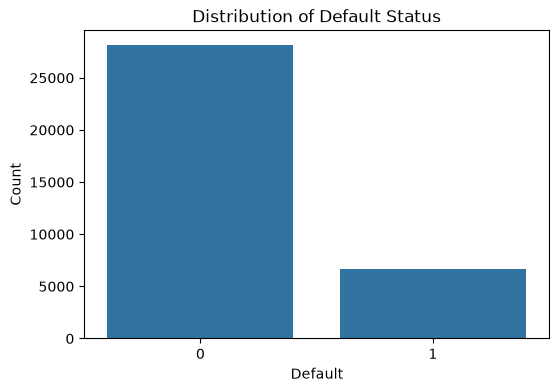

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df[target]
)

plt.title("Distribution of Default Status")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

#### The target variable is highly imbalanced, with non-default customers representing the majority class and default customers accounting for a much smaller proportion of observations. Such imbalance can bias machine learning models toward predicting the majority class, justifying the later use of SMOTE.

### Descriptive Statistics

In [18]:
features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM",
    "LIMIT_BAL_LOG"
]

summary_stats = pd.DataFrame({
    "Mean": df[features].mean(),
    "Median": df[features].median(),
    "Std Dev": df[features].std()
})

summary_stats.round(2)

,Mean,Median,Std Dev
LIMIT_BAL,184668.99,140000.00,235931.93
AGE,35.52,34.00,9.24
BILL_AMT_SUM,294815.17,129037.00,571807.25
LIMIT_BAL_LOG,11.70,11.85,0.97


In [19]:
# Additional skewness analysis
skewness = pd.DataFrame({
    "Skewness": df[features].skew()
})

skewness.round(2)

,Skewness
LIMIT_BAL,9.11
AGE,0.74
BILL_AMT_SUM,11.13
LIMIT_BAL_LOG,-0.34


### Distribution of Numerical Variables

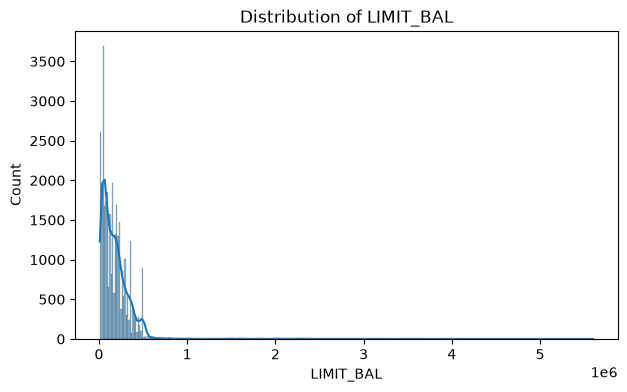

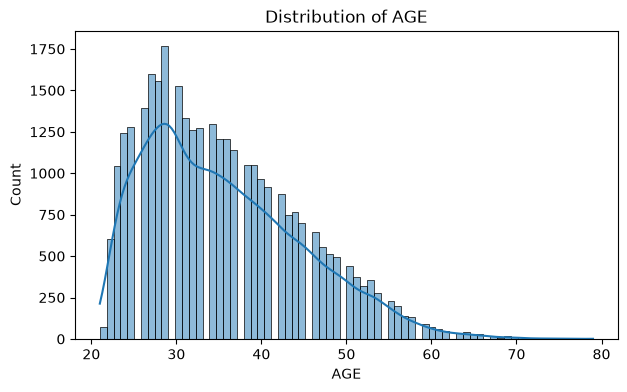

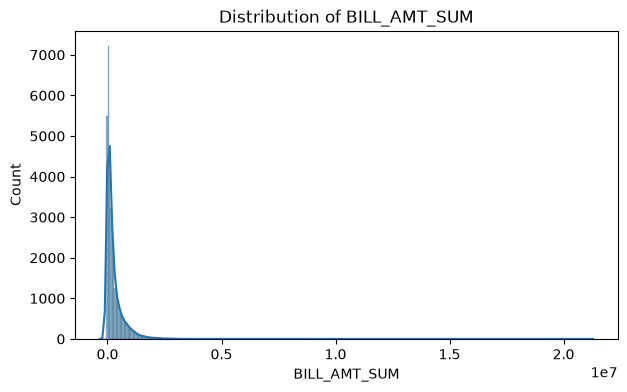

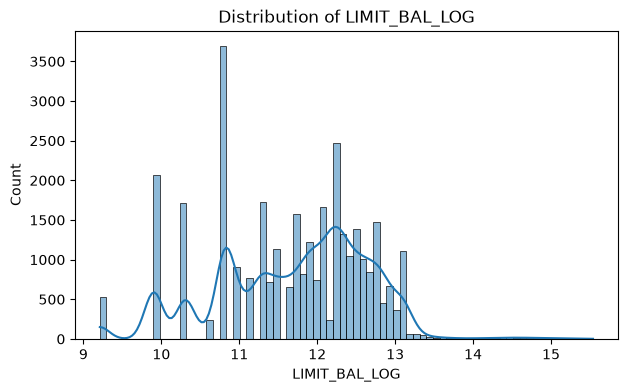

In [20]:
num_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT_SUM",
    "LIMIT_BAL_LOG"
]

for col in num_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.show()

### Outlier Analysis

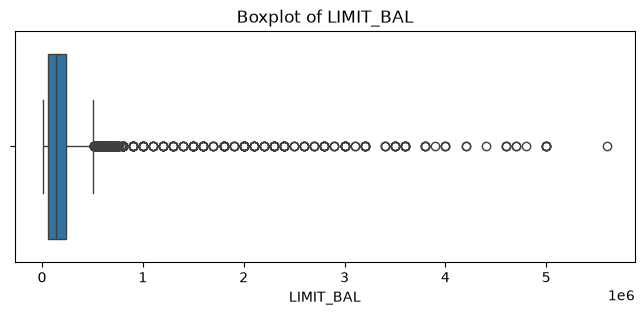

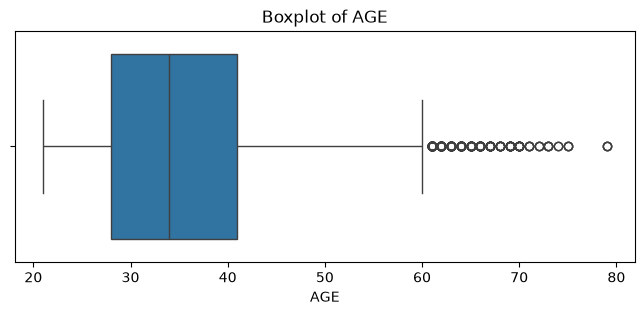

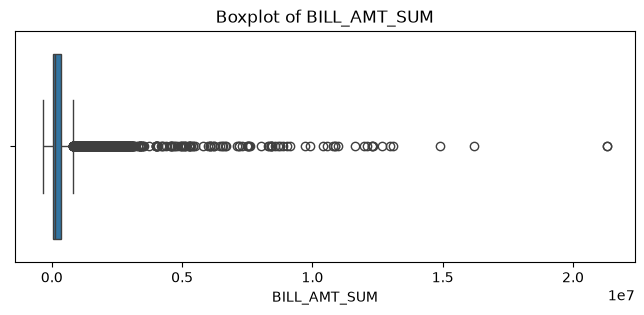

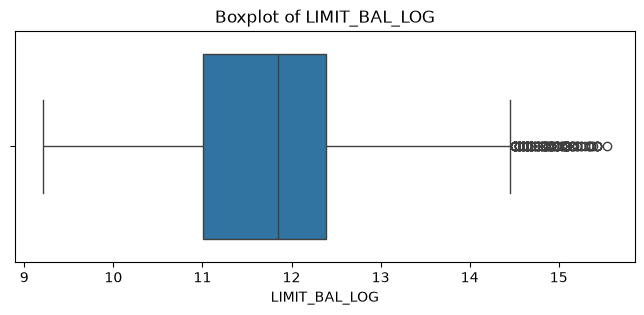

In [21]:
for col in num_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        f"Boxplot of {col}"
    )

    plt.show()

### Interpretation

Several variables contain significant outliers.

The most pronounced outliers appear in:

- LIMIT_BAL
- BILL_AMT_SUM

These observations may represent genuine high-value customers rather than errors.

Therefore, outliers will be retained but appropriate scaling methods will be applied during preprocessing.

### Distribution of Categorical Variables

In [22]:
cat_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "CITY",
    "RISK_RATING"
]

for col in cat_cols:

    print("\n" + "="*20)
    print(col)
    print("="*20)

    print(df[col].value_counts(dropna=False))


SEX
SEX
2.0    19953
1.0    13068
NaN     1767
Name: count, dtype: int64

EDUCATION
EDUCATION
2.0    15392
1.0    11724
3.0     5421
NaN     1734
5.0      306
4.0      140
6.0       55
0.0       16
Name: count, dtype: int64

MARRIAGE
MARRIAGE
2.0    17570
1.0    15080
NaN     1733
3.0      348
0.0       57
Name: count, dtype: int64

CITY
CITY
City_47    763
City_32    748
City_25    740
City_3     738
City_17    733
City_36    729
City_42    728
City_40    727
City_50    726
City_7     723
City_15    723
City_9     722
City_21    718
City_8     718
City_48    713
City_19    712
City_4     711
City_27    711
City_22    710
City_1     708
City_46    707
City_23    705
City_45    705
City_41    702
City_16    699
City_33    699
City_35    697
City_34    695
City_37    694
City_18    692
City_10    690
City_6     685
City_2     684
City_29    683
City_39    680
City_49    676
City_13    676
City_28    675
City_30    674
City_11    672
City_24    672
City_43    669
City_44    661
City_20  

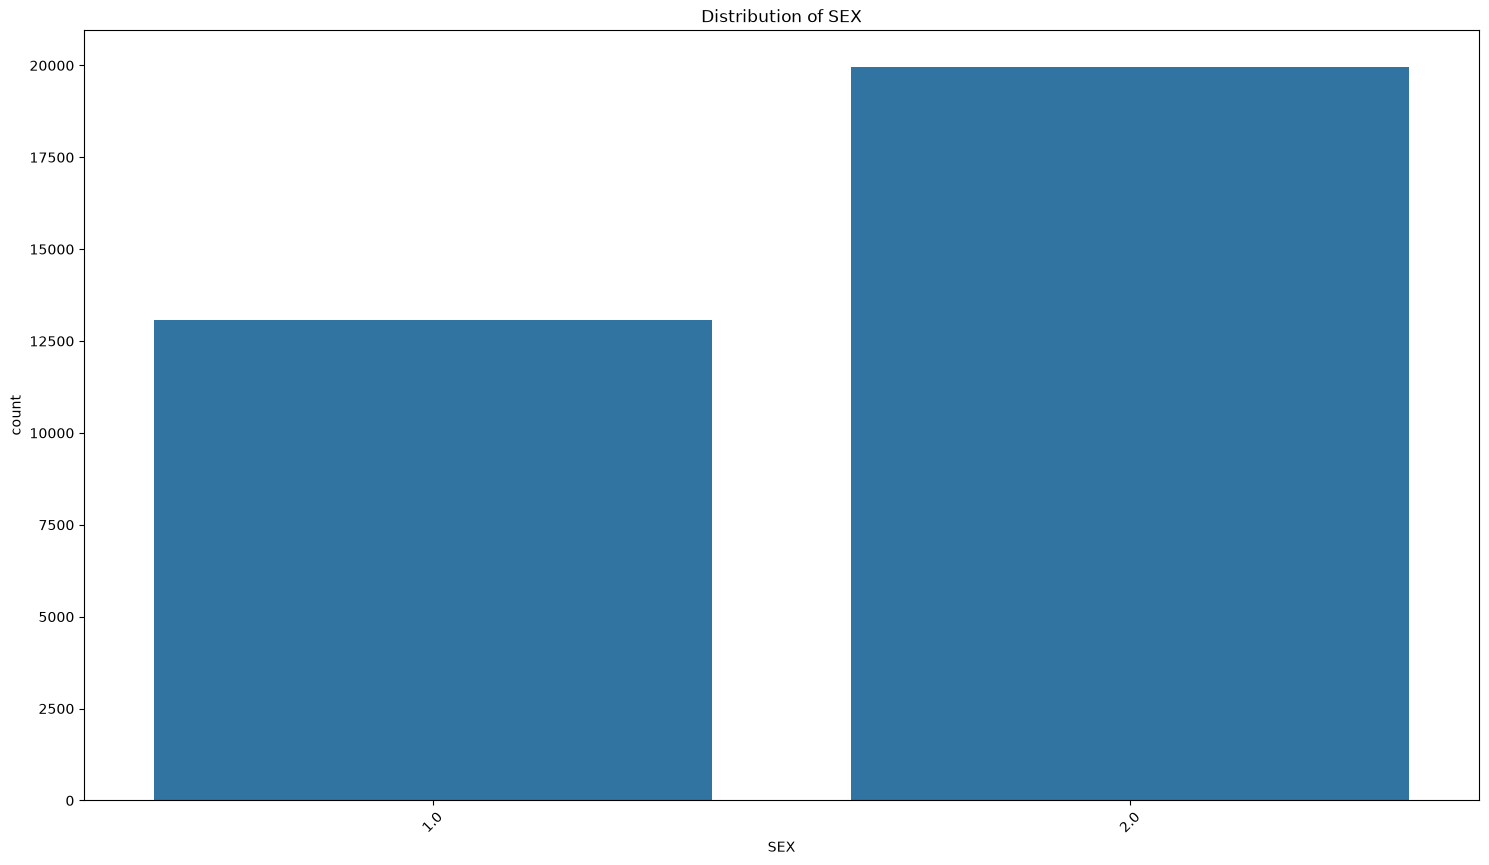

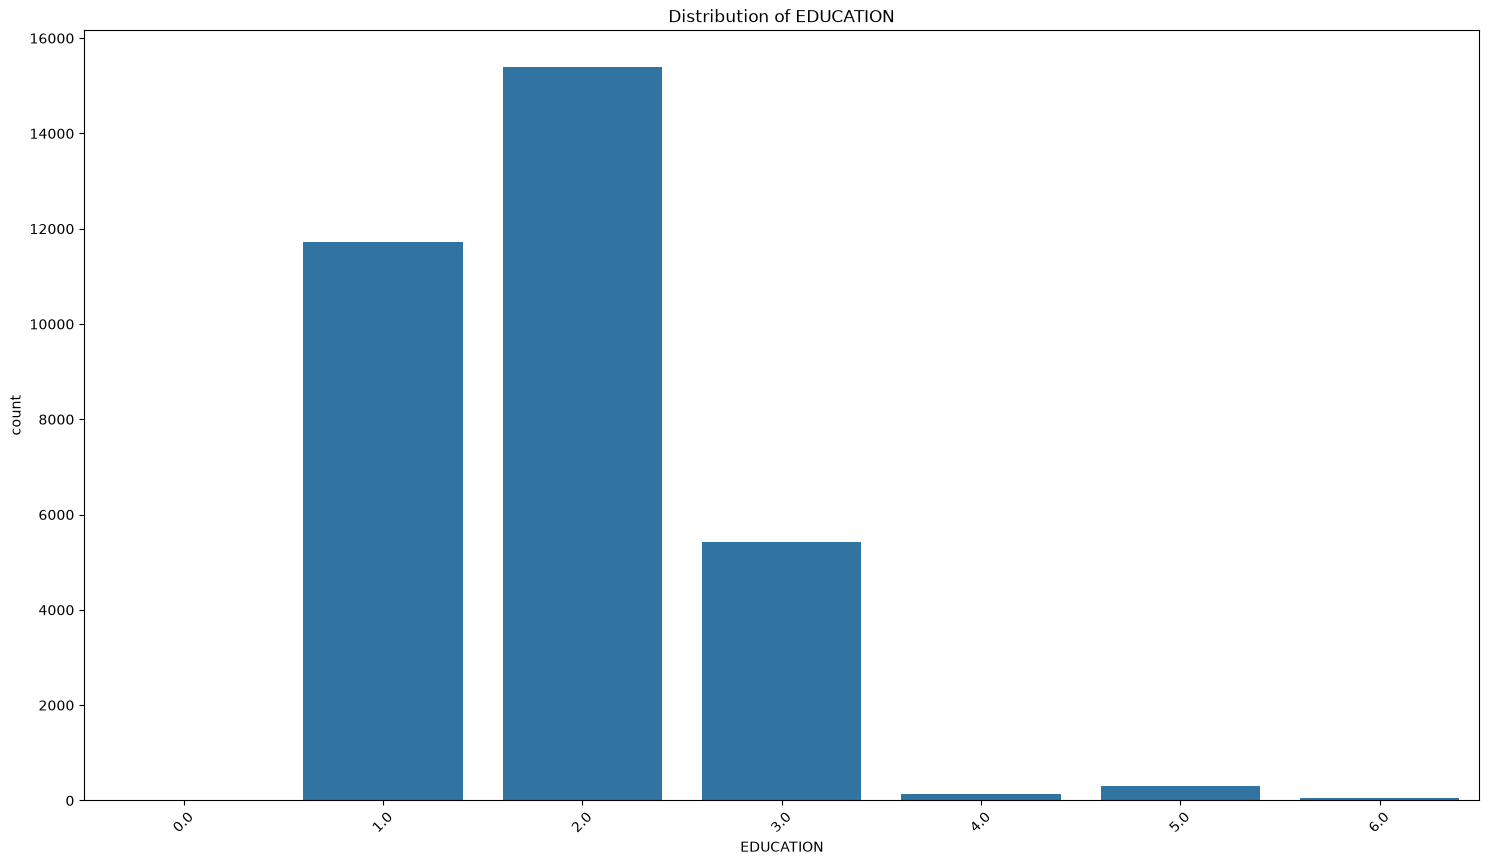

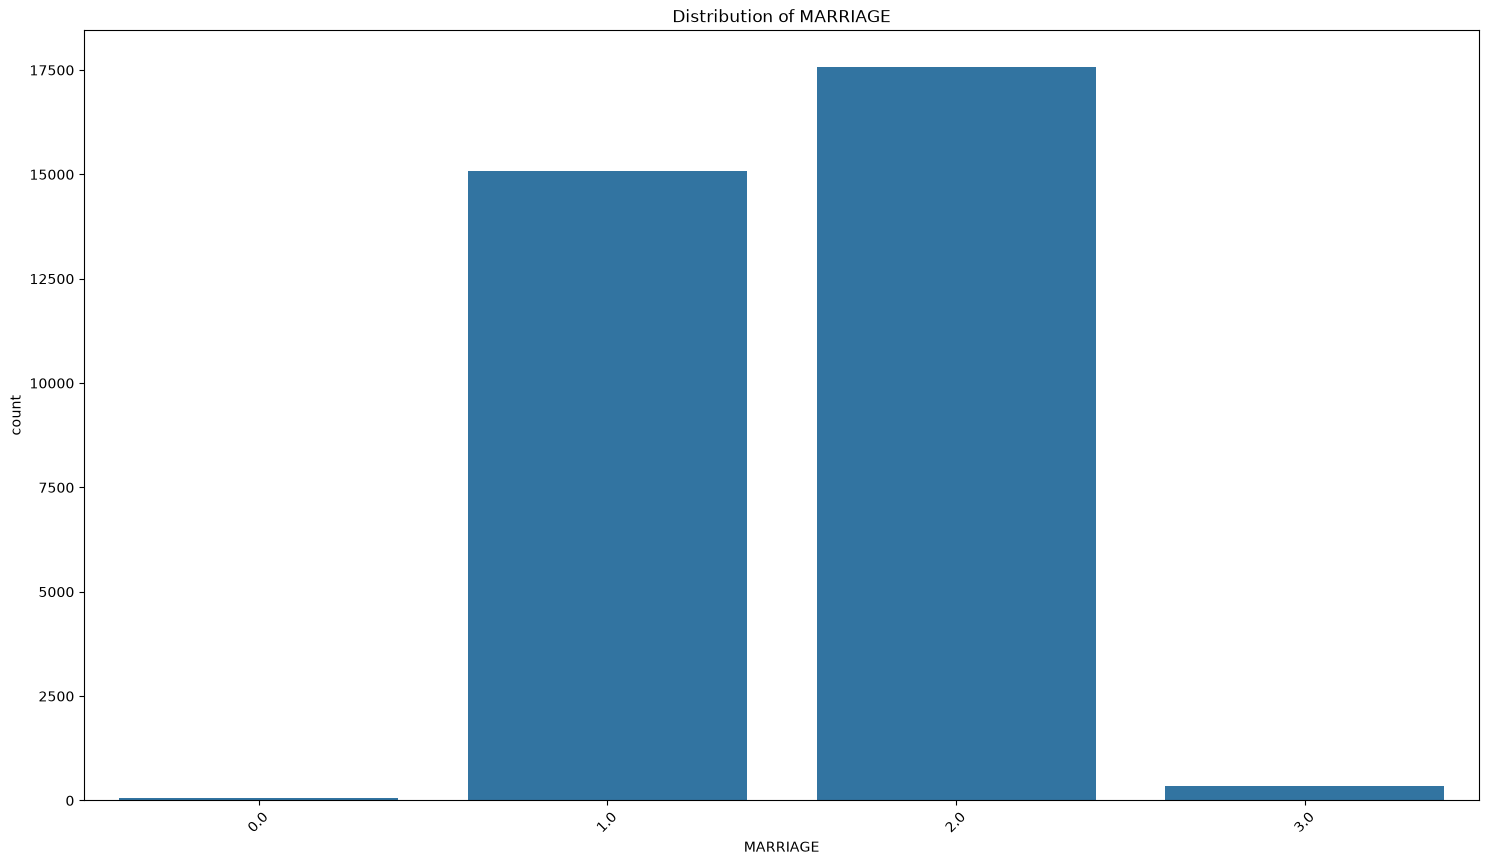

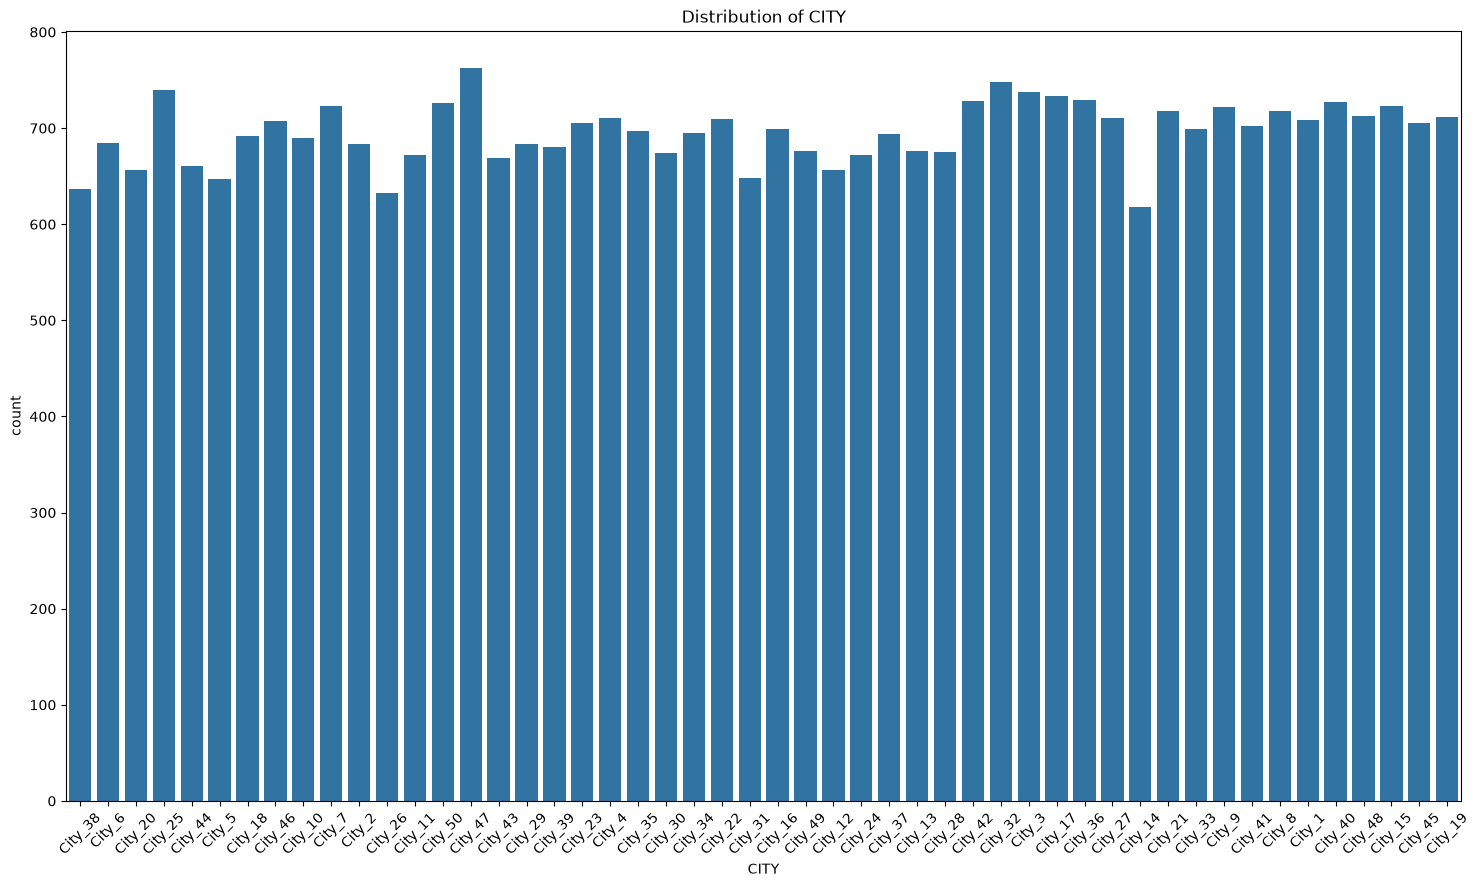

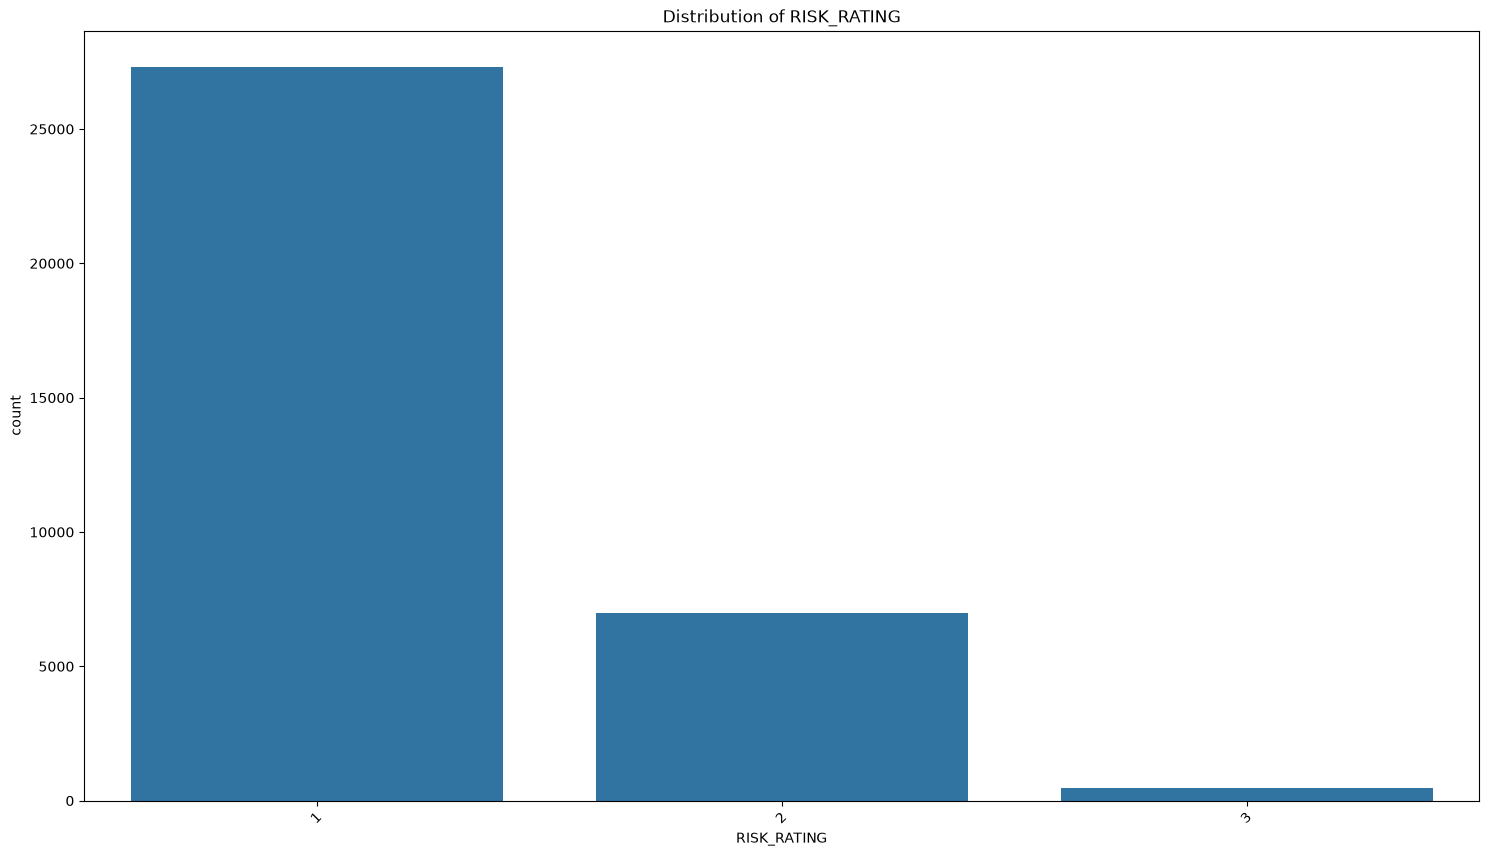

In [23]:
for col in cat_cols:

    plt.figure(figsize=(18,10))

    sns.countplot(
        x=df[col]
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.xticks(rotation=45)

    plt.show()

### Default Rate by Category

In [24]:
target = "default.payment.next.month"

for col in cat_cols:

    default_rate = (
        df.groupby(col)[target]
        .mean()
        .sort_values(ascending=False)
    )

    print("\n")
    print(col)

    display(
        round(default_rate * 100, 2)
    )



SEX


SEX
1.0    20.97
2.0    18.07
Name: default.payment.next.month, dtype: float64



EDUCATION


EDUCATION
3.0    21.80
2.0    20.67
1.0    16.43
6.0    14.55
5.0     5.56
4.0     5.00
0.0     0.00
Name: default.payment.next.month, dtype: float64



MARRIAGE


MARRIAGE
3.0    23.28
1.0    20.39
2.0    17.98
0.0     8.77
Name: default.payment.next.month, dtype: float64



CITY


CITY
City_14    25.08
City_48    22.30
City_12    21.34
City_16    21.17
City_5     21.02
City_34    20.86
City_4     20.82
City_50    20.66
City_28    20.30
City_13    20.27
City_43    20.03
City_10    20.00
City_44    19.97
City_31    19.75
City_2     19.74
City_22    19.58
City_6     19.56
City_46    19.52
City_29    19.47
City_37    19.45
City_49    19.38
City_8     19.36
City_27    19.27
City_39    19.26
City_21    19.22
City_38    19.15
City_26    19.12
City_15    19.09
City_9     18.98
City_47    18.87
City_23    18.87
City_30    18.84
City_18    18.79
City_3     18.70
City_42    18.68
City_24    18.60
City_1     18.36
City_32    18.18
City_17    18.14
City_36    17.97
City_45    17.87
City_33    17.60
City_19    17.56
City_41    17.38
City_25    17.30
City_11    16.96
City_35    16.79
City_40    16.51
City_7     16.18
City_20    16.16
Name: default.payment.next.month, dtype: float64



RISK_RATING


RISK_RATING
3    68.10
2    44.36
1    11.79
Name: default.payment.next.month, dtype: float64

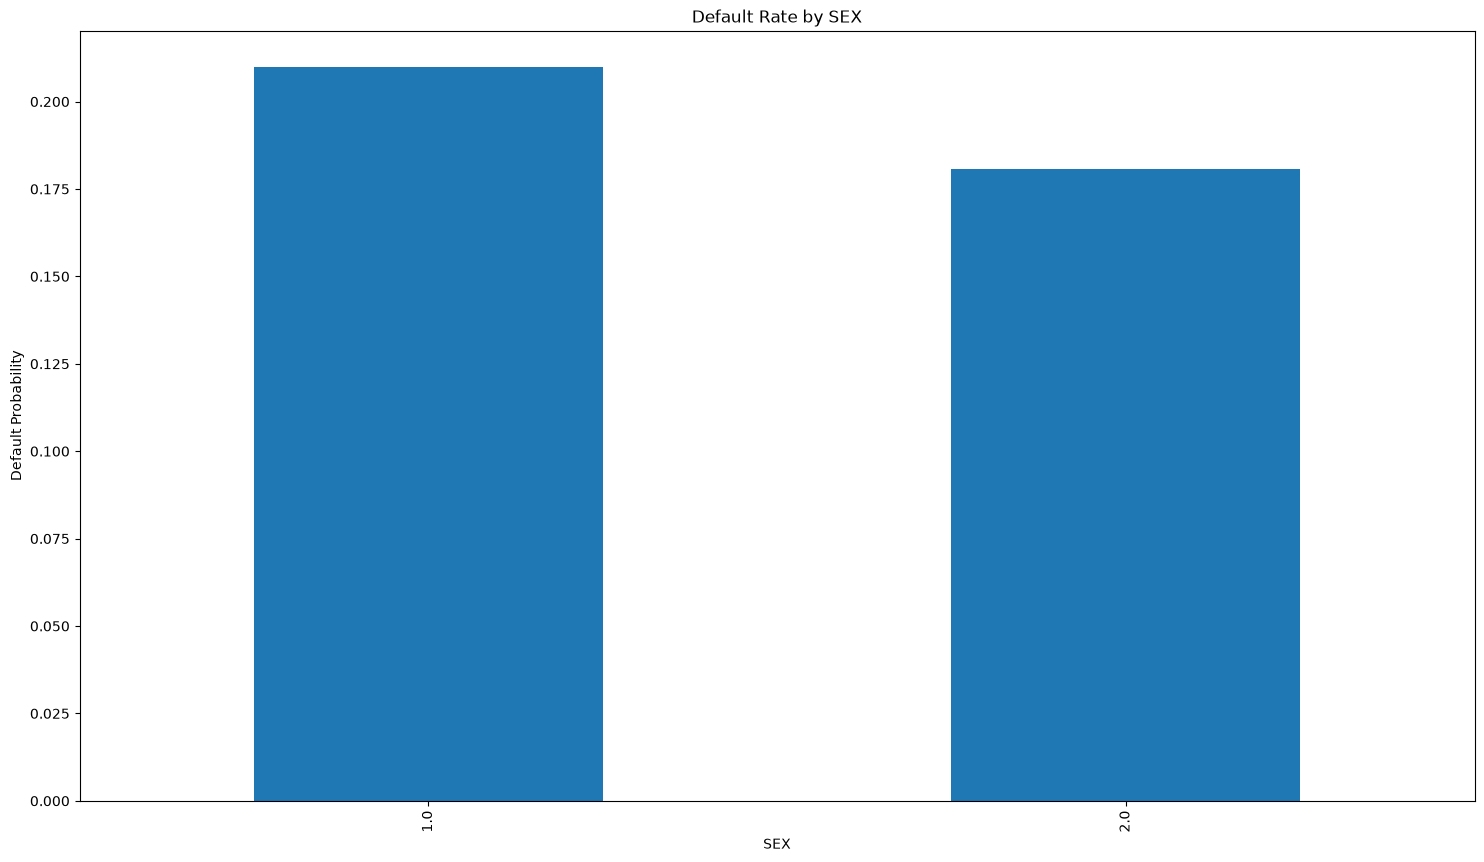

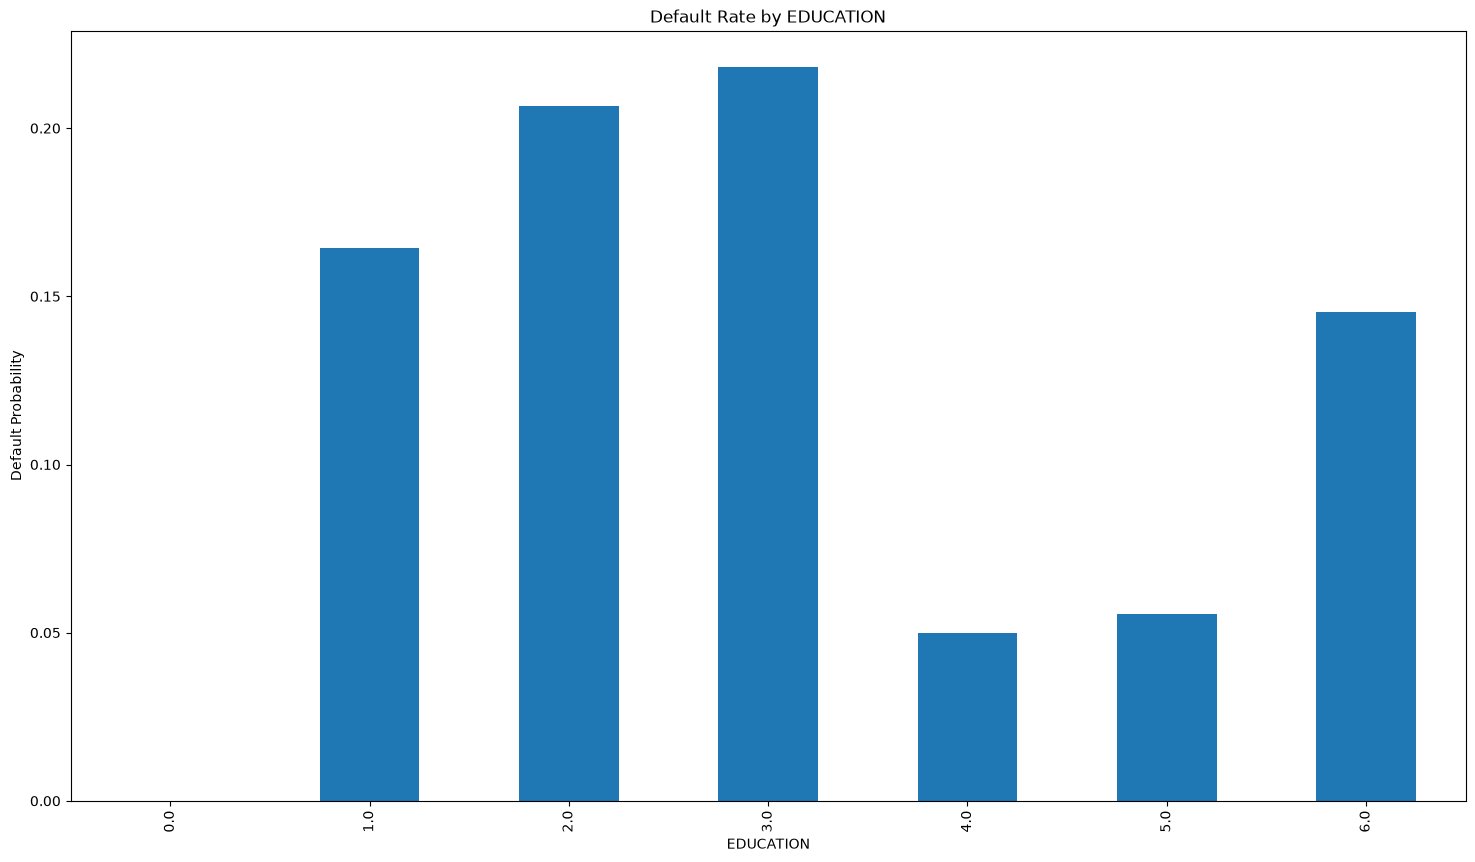

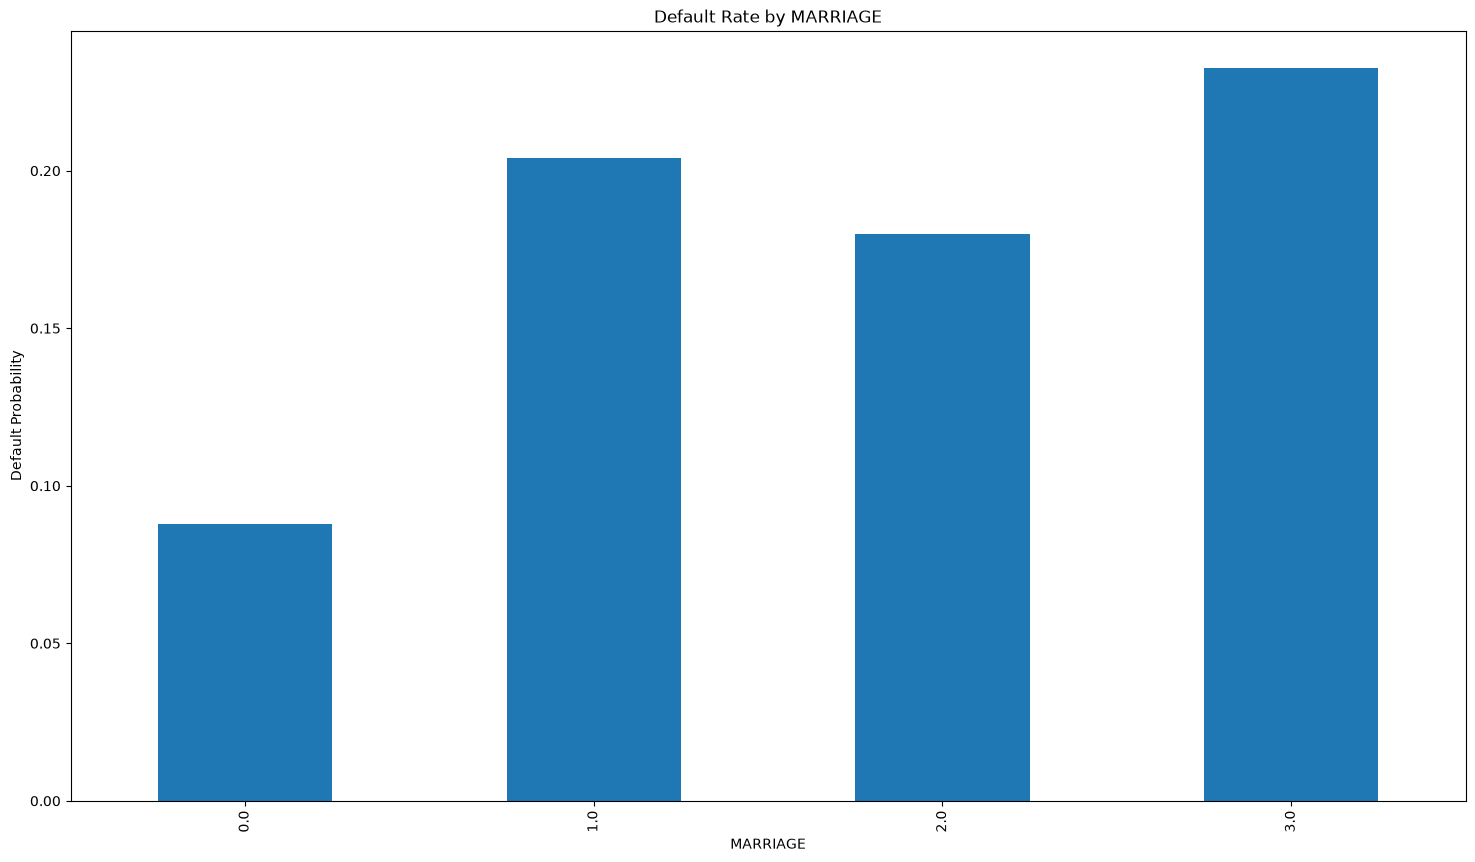

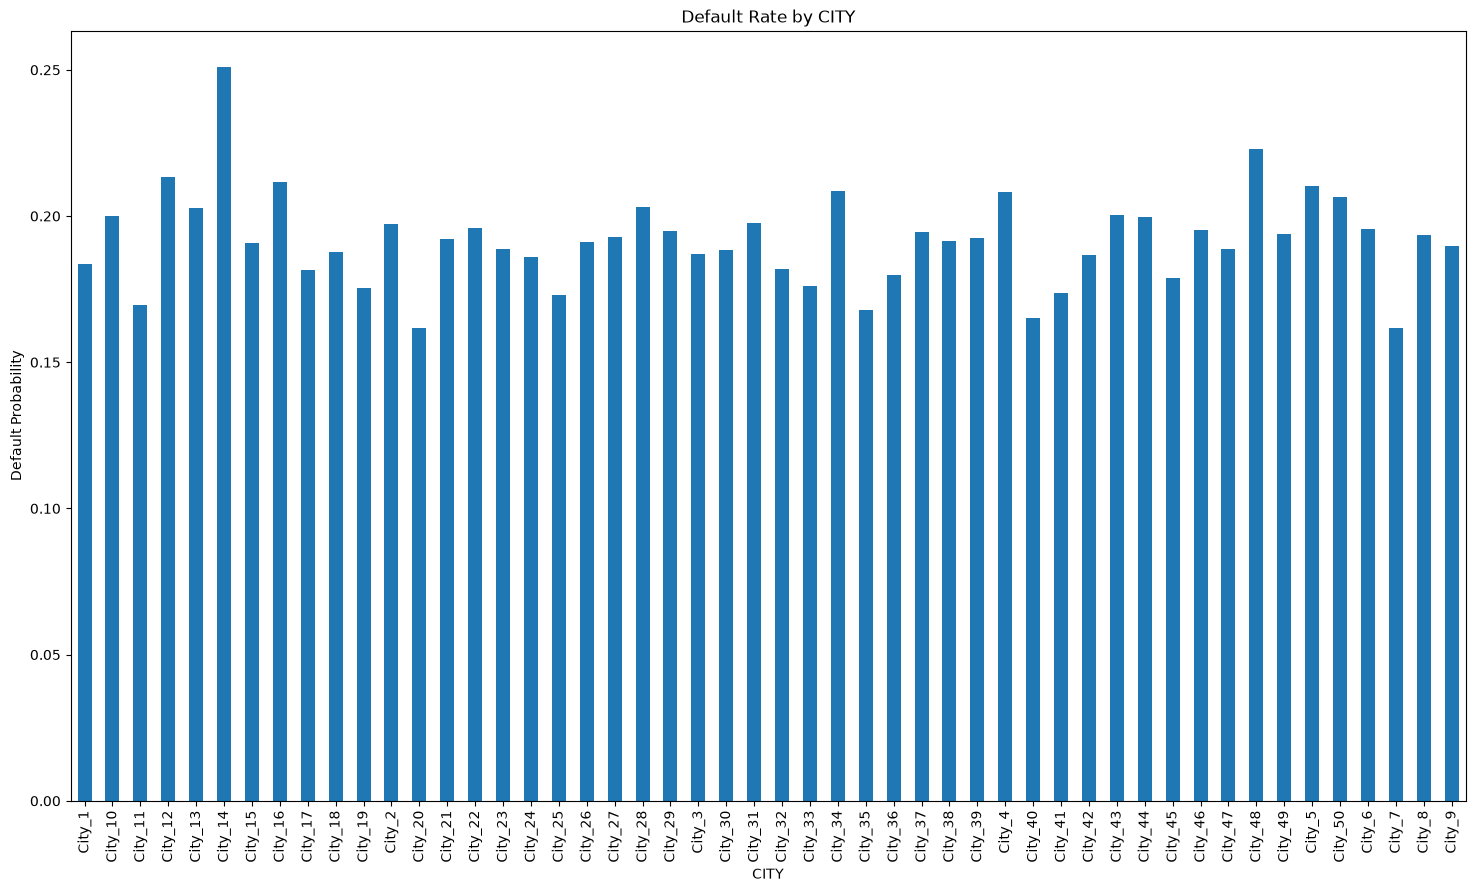

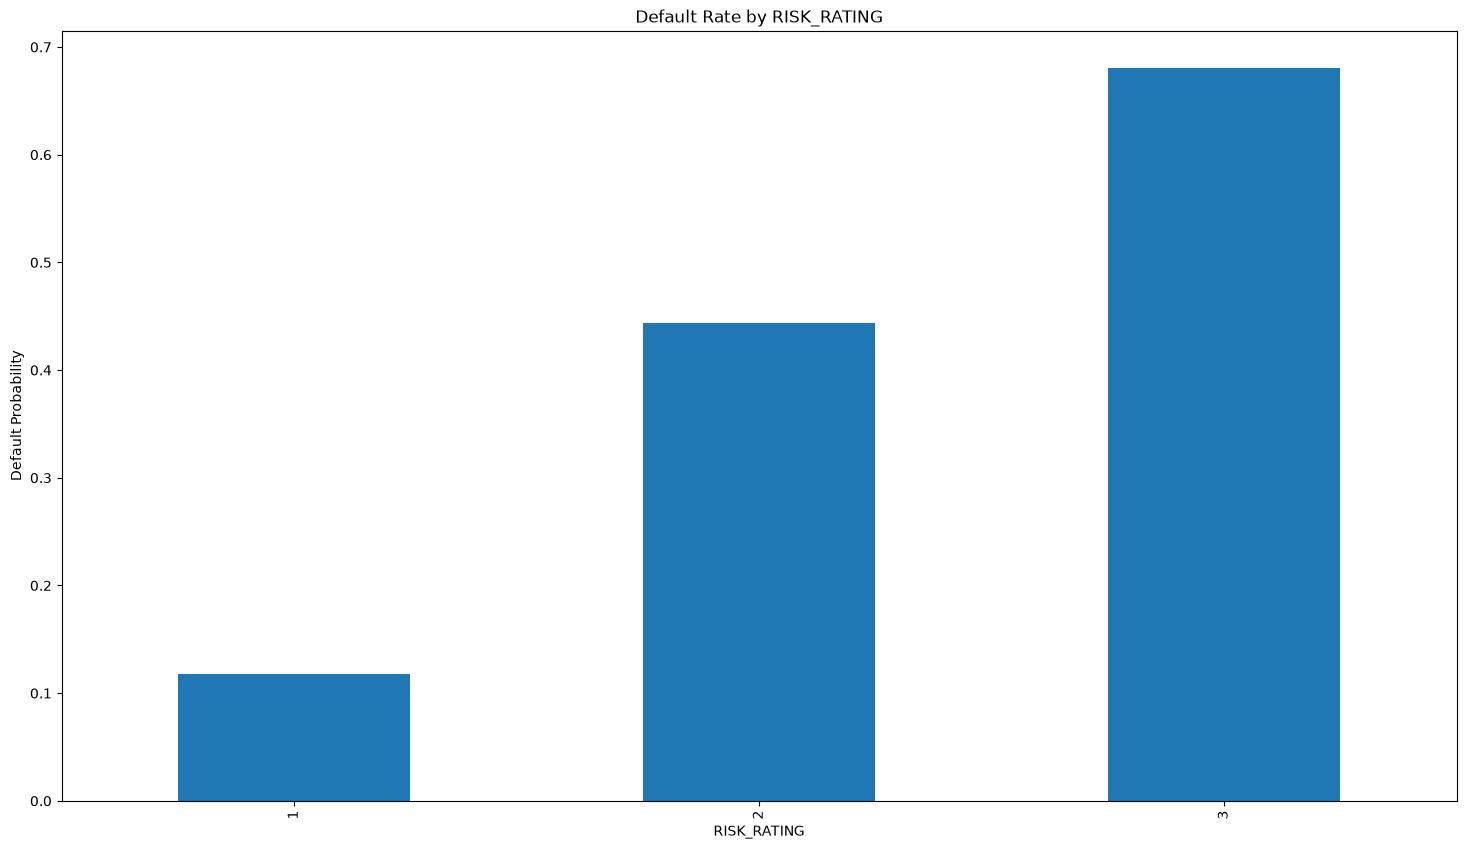

In [25]:
for col in cat_cols:

    plt.figure(figsize=(18,10))

    default_rate = (
        df.groupby(col)[target]
        .mean()
    )

    default_rate.plot(
        kind="bar"
    )

    plt.ylabel(
        "Default Probability"
    )

    plt.title(
        f"Default Rate by {col}"
    )

    plt.show()

### Correlation Analysis

In [26]:
corr_matrix = df.corr(
    numeric_only=True
)

corr_matrix.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL_AMT_SUM,LIMIT_BAL_LOG,RISK_RATING
ID,1.000000,0.012802,0.021618,0.035382,-0.025975,0.016610,-0.034856,-0.015506,-0.022850,-0.006976,...,0.010259,0.005446,0.039357,0.005520,0.002636,-0.000190,-0.012775,0.011773,0.029190,-0.023751
LIMIT_BAL,0.012802,1.000000,0.017438,-0.139328,-0.061567,0.078747,-0.160722,-0.180083,-0.175508,-0.164977,...,0.109463,0.097699,0.113755,0.111336,0.122518,0.131092,-0.089601,0.462752,0.682410,-0.090839
SEX,0.021618,0.017438,1.000000,0.010975,-0.033621,-0.088290,-0.058564,-0.072661,-0.067081,-0.060919,...,-0.001421,0.003601,-0.011931,-0.003073,-0.002921,-0.003892,-0.036020,-0.017912,0.075652,-0.029008
EDUCATION,0.035382,-0.139328,0.010975,1.000000,-0.143277,0.175549,0.107178,0.121153,0.115307,0.109261,...,-0.037739,-0.029860,-0.039147,-0.033417,-0.039442,-0.037033,0.028543,0.001283,-0.222852,0.036551
MARRIAGE,-0.025975,-0.061567,-0.033621,-0.143277,1.000000,-0.413327,0.022582,0.025098,0.034260,0.032774,...,-0.004785,-0.011667,-0.004969,-0.011020,-0.002737,-0.007552,-0.024416,-0.020112,-0.115501,-0.011111


In [27]:
target_corr = (
    corr_matrix[target]
    .sort_values(ascending=False)
)

target_corr

default.payment.next.month    1.000000
RISK_RATING                   0.362487
PAY_0                         0.314230
PAY_2                         0.253757
PAY_3                         0.224862
PAY_4                         0.207571
PAY_5                         0.196277
PAY_6                         0.179303
EDUCATION                     0.028543
AGE                           0.011700
BILL_AMT6                    -0.005909
BILL_AMT5                    -0.007094
BILL_AMT4                    -0.009931
BILL_AMT_SUM                 -0.010079
ID                           -0.012775
BILL_AMT3                    -0.013771
BILL_AMT2                    -0.014030
BILL_AMT1                    -0.018940
MARRIAGE                     -0.024416
SEX                          -0.036020
PAY_AMT6                     -0.049474
PAY_AMT2                     -0.051469
PAY_AMT5                     -0.052321
PAY_AMT4                     -0.052782
PAY_AMT3                     -0.053304
PAY_AMT1                 

In [28]:
top_corr = pd.DataFrame({
    "Correlation With Default":
        target_corr
})

top_corr.head(20)

,Correlation With Default
default.payment.next.month,1.000000
RISK_RATING,0.362487
PAY_0,0.314230
PAY_2,0.253757
PAY_3,0.224862
PAY_4,0.207571
PAY_5,0.196277
PAY_6,0.179303
EDUCATION,0.028543
AGE,0.011700


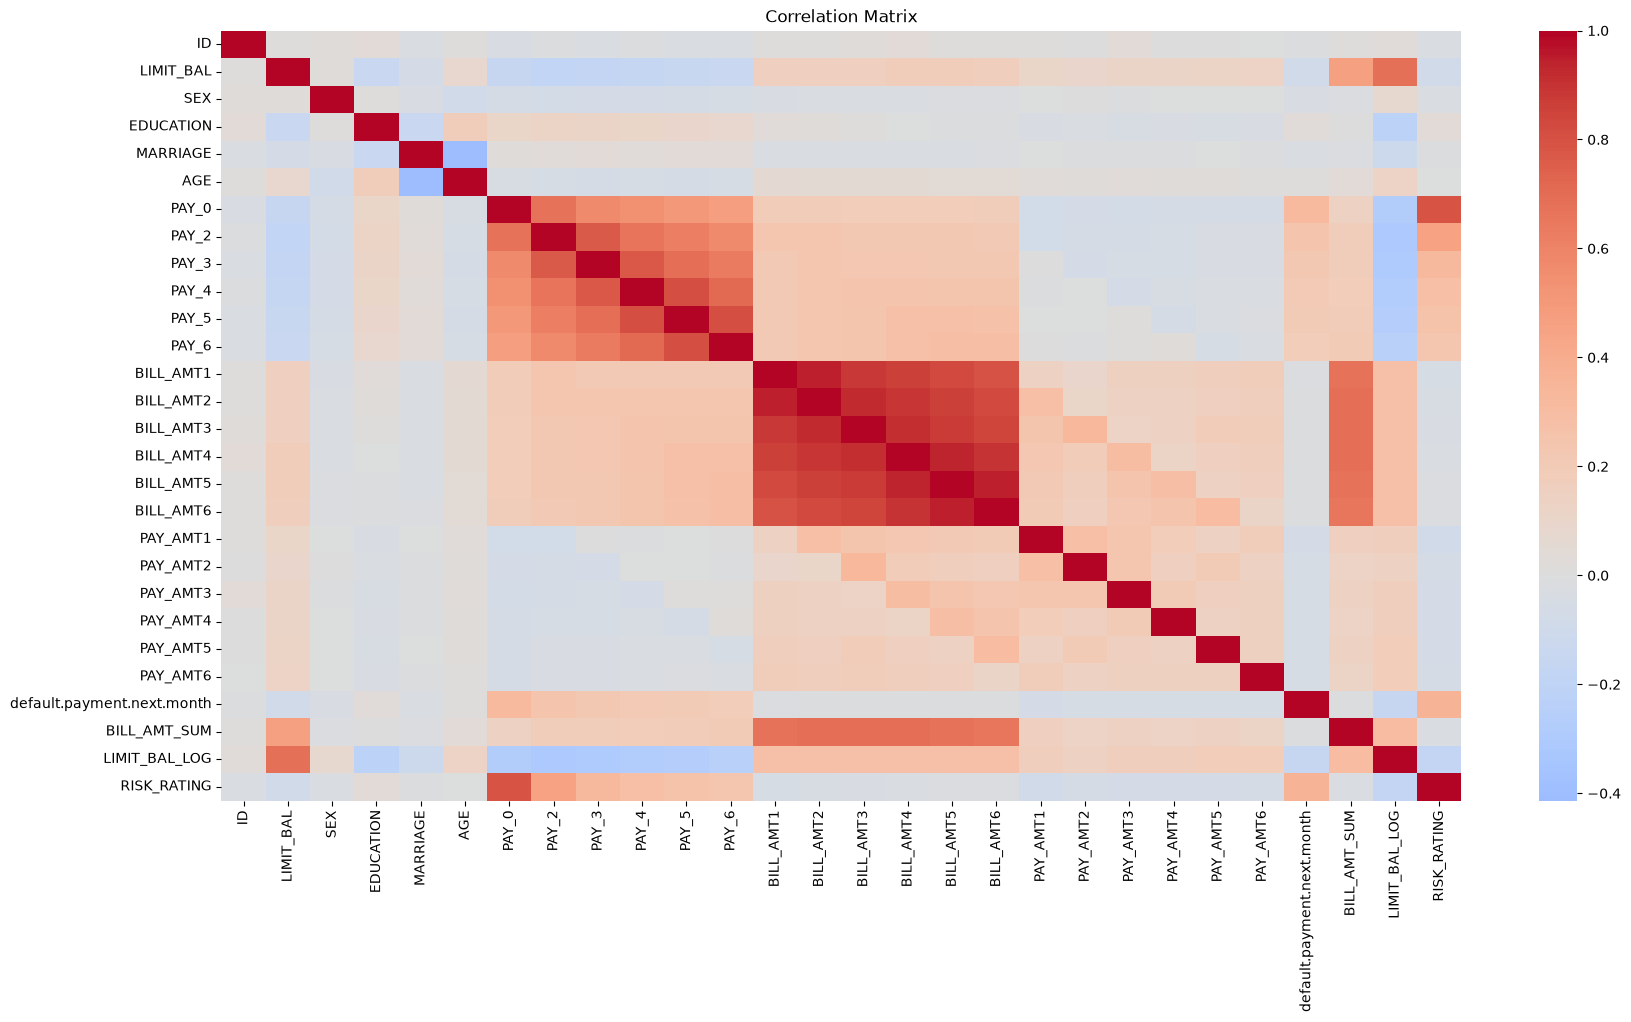

In [29]:
plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.show()

### Analysis of Payment History Variables

In [30]:
pay_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

pay_corr = (
    df[
        pay_cols +
        [target]
    ]
    .corr()
)

pay_corr[target]

PAY_0                         0.314230
PAY_2                         0.253757
PAY_3                         0.224862
PAY_4                         0.207571
PAY_5                         0.196277
PAY_6                         0.179303
default.payment.next.month    1.000000
Name: default.payment.next.month, dtype: float64

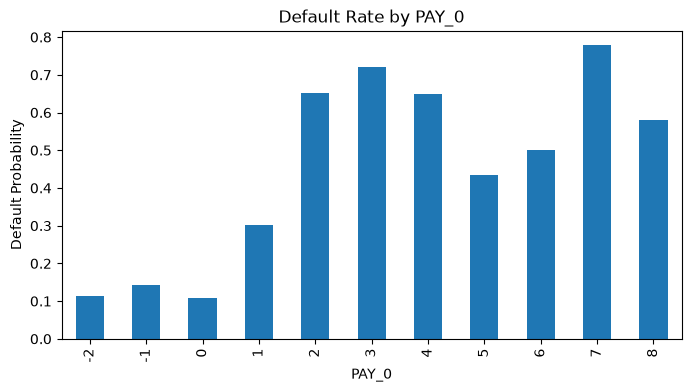

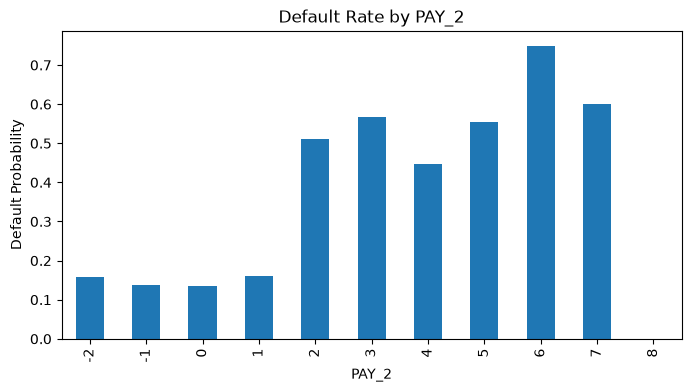

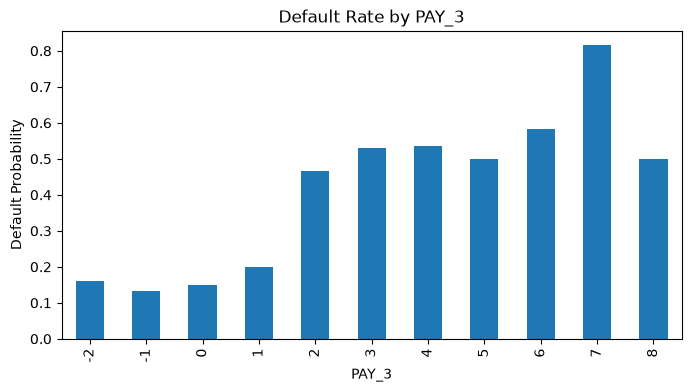

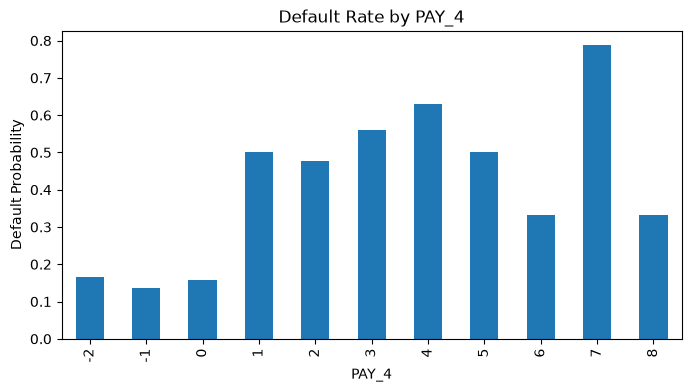

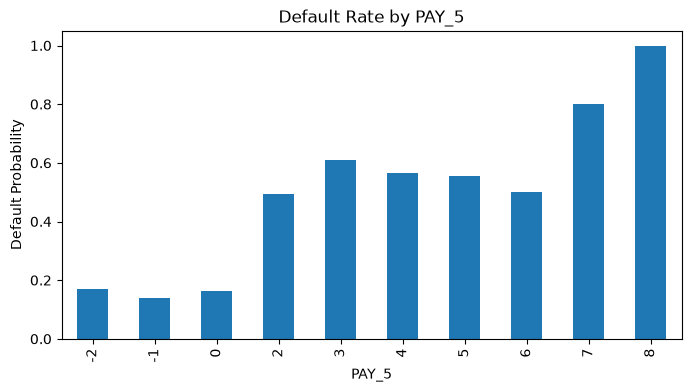

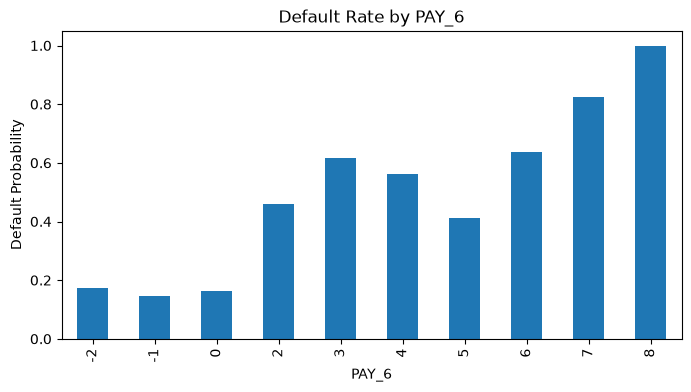

In [31]:
for col in pay_cols:

    plt.figure(figsize=(8,4))

    default_rate = (
        df.groupby(col)[target]
        .mean()
    )

    default_rate.plot(
        kind="bar"
    )

    plt.ylabel(
        "Default Probability"
    )

    plt.title(
        f"Default Rate by {col}"
    )

    plt.show()

### Investigation of risk_leak

In [32]:
print(df["risk_leak"].dtype)

print(df["risk_leak"].value_counts())

object
risk_leak
 -0.11320834240277491     4
 -0.001475687188285091    4
 0.12192207445080144      4
 -0.0596191205691874      4
 0.012204282449871946     4
                         ..
-0.294219                 1
-0.030988                 1
-0.09803                  1
 0.013425                 1
 0.041649                 1
Name: count, Length: 31929, dtype: int64


In [33]:
pd.crosstab(
    df["risk_leak"],
    df[target],
    normalize="index"
)

default.payment.next.month,0,1
risk_leak,,
-0.320734,1.0,0.0
-0.299363,1.0,0.0
-0.294219,1.0,0.0
-0.286595,1.0,0.0
-0.267757,1.0,0.0
...,...,...
"6,26E+10",1.0,0.0
"6,64E+09",1.0,0.0
"7,60E+10",1.0,0.0


In [34]:
risk_leak_default = pd.crosstab(
    df["risk_leak"],
    df[target],
    normalize="index"
)

risk_leak_default

default.payment.next.month,0,1
risk_leak,,
-0.320734,1.0,0.0
-0.299363,1.0,0.0
-0.294219,1.0,0.0
-0.286595,1.0,0.0
-0.267757,1.0,0.0
...,...,...
"6,26E+10",1.0,0.0
"6,64E+09",1.0,0.0
"7,60E+10",1.0,0.0


## Task 2: Data Preprocessing

In [35]:
# Create working copy
df_processed = df.copy()

print(df_processed.shape)

(34788, 30)


### Duplicate Record Handling

In [36]:
duplicates = df_processed.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 2858


In [37]:
if duplicates > 0:
    df_processed = df_processed.drop_duplicates()

print("New Shape:", df_processed.shape)

New Shape: (31930, 30)


### Missing Value Treatment

In [38]:
missing_before = df_processed.isnull().sum()

missing_before[
    missing_before > 0
]

LIMIT_BAL        1582
SEX              1607
EDUCATION        1600
MARRIAGE         1586
AGE              1604
PAY_AMT1         1585
PAY_AMT2         1608
LIMIT_BAL_LOG    1582
dtype: int64

In [39]:
num_missing_cols = [
    "LIMIT_BAL",
    "AGE",
    "PAY_AMT1",
    "PAY_AMT2"
]

for col in num_missing_cols:
    df_processed[col] = df_processed[col].fillna(
        df_processed[col].median()
    )

In [40]:
cat_missing_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

for col in cat_missing_cols:
    df_processed[col] = df_processed[col].fillna(
        df_processed[col].mode()[0]
    )

In [41]:
missing_after = df_processed.isnull().sum()

missing_after[
    missing_after > 0
]

LIMIT_BAL_LOG    1582
dtype: int64

### Correcting LIMIT_BAL_LOG

In [42]:
import numpy as np

df_processed["LIMIT_BAL_LOG"] = np.log1p(
    df_processed["LIMIT_BAL"]
)

In [43]:
df_processed[
    [
        "LIMIT_BAL",
        "LIMIT_BAL_LOG"
    ]
].head()

,LIMIT_BAL,LIMIT_BAL_LOG
0,20000.0,9.903538
1,120000.0,11.695255
2,90000.0,11.407576
3,50000.0,10.819798
4,50000.0,10.819798


In [44]:
df_processed["LIMIT_BAL_LOG"].describe()

count    31930.000000
mean        11.700524
std          0.944739
min          9.210440
25%         11.002117
50%         11.849405
75%         12.388398
max         15.538277
Name: LIMIT_BAL_LOG, dtype: float64

### risk_leak Investigation

In [45]:
print(df_processed["risk_leak"].value_counts())

risk_leak
 -9,27E+10                 2
 1.075.675.276.433.290     1
 10.940.840.854.872.400    1
 0.0703022492301175        1
 0.058442435467177846      1
                          ..
-0.294219                  1
-0.030988                  1
-0.09803                   1
 0.013425                  1
 0.041649                  1
Name: count, Length: 31929, dtype: int64


In [46]:
pd.crosstab(
    df_processed["risk_leak"],
    df_processed["default.payment.next.month"],
    normalize="index"
)

default.payment.next.month,0,1
risk_leak,,
-0.320734,1.0,0.0
-0.299363,1.0,0.0
-0.294219,1.0,0.0
-0.286595,1.0,0.0
-0.267757,1.0,0.0
...,...,...
"6,26E+10",1.0,0.0
"6,64E+09",1.0,0.0
"7,60E+10",1.0,0.0


In [47]:
risk_check = pd.crosstab(
    df_processed["risk_leak"],
    df_processed["default.payment.next.month"],
    normalize="index"
)

risk_check

default.payment.next.month,0,1
risk_leak,,
-0.320734,1.0,0.0
-0.299363,1.0,0.0
-0.294219,1.0,0.0
-0.286595,1.0,0.0
-0.267757,1.0,0.0
...,...,...
"6,26E+10",1.0,0.0
"6,64E+09",1.0,0.0
"7,60E+10",1.0,0.0


In [48]:
df_processed.drop(
    columns=["risk_leak"],
    inplace=True
)

print("risk_leak removed")

risk_leak removed


### Removal of risk_leak

The original dataset contained a variable named risk_leak. Preliminary investigation suggested that the feature represented information that could potentially reveal the target outcome and therefore introduce data leakage.

To ensure a realistic evaluation scenario and prevent artificially inflated model performance, the variable was removed prior to model training.

The final modelling dataset therefore excludes risk_leak.

### Encoding Categorical Variables

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_processed["CITY"] = le.fit_transform(
    df_processed["CITY"]
)
df_processed.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,2.0,24.0,2,2,-1,-1,...,689.0,0.0,0.0,0.0,0.0,1,7704.0,9.903538,31,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,1000.0,0.0,2000.0,1,17077.0,11.695255,46,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1500.0,1000.0,1000.0,1000.0,5000.0,0,101653.0,11.407576,12,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,2019.0,1200.0,1100.0,1069.0,1000.0,0,231334.0,10.819798,17,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,36681.0,10000.0,9000.0,689.0,679.0,0,109339.0,10.819798,38,1


### Feature and Target Separation

In [50]:
target = "default.payment.next.month"

X = df_processed.drop(
    columns=[target]
)

y = df_processed[target]

print(X.shape)
print(y.shape)

(31930, 28)
(31930,)


### Train Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(25544, 28)
(6386, 28)


### Feature Scaling

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [53]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(25544, 28)
(6386, 28)


### Handling Class Imbalance Using SMOTE

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [55]:
print("Before SMOTE")

print(
    y_train.value_counts()
)

print("\nAfter SMOTE")

print(
    y_train_smote.value_counts()
)

Before SMOTE
default.payment.next.month
0    20235
1     5309
Name: count, dtype: int64

After SMOTE
default.payment.next.month
0    20235
1    20235
Name: count, dtype: int64


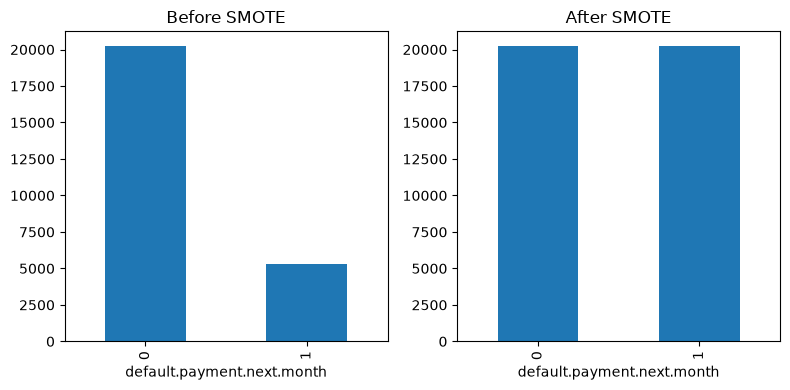

In [56]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

y_train.value_counts().plot(
    kind="bar"
)

plt.title("Before SMOTE")

plt.subplot(1,2,2)

y_train_smote.value_counts().plot(
    kind="bar"
)

plt.title("After SMOTE")

plt.tight_layout()

plt.show()

## Justification

The dataset has now been fully prepared for machine learning.

The preprocessing pipeline included:

- Duplicate removal
- Missing value imputation
- Correction of malformed variables
- Leakage assessment
- Encoding
- Scaling
- Stratified train-test split
- SMOTE balancing

The resulting dataset is suitable for classification modelling.

## Task 3 :  Model Training

### Machine Learning Model Development

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

# Model Initialisation
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=500,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=500,
            random_state=42
        )
}

###  Model Training

In [58]:
for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    print(f"{name} trained successfully")

Logistic Regression trained successfully
Random Forest trained successfully
XGBoost trained successfully
AdaBoost trained successfully
MLP trained successfully


### Prediction Generation


In [59]:
predictions = {}
probabilities = {}

for name, model in models.items():

    predictions[name] = model.predict(
        X_test_scaled
    )

    probabilities[name] = model.predict_proba(
        X_test_scaled
    )[:,1]

print("Predictions generated successfully")

Predictions generated successfully


## Task 4: Model Evaluation and Visualisation

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

### Performance Table

In [61]:
results = []

for name in models.keys():

    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.8276,0.6239,0.4288,0.5083,0.8112
2,XGBoost,0.8227,0.6242,0.3693,0.4640,0.7624
3,AdaBoost,0.7805,0.4740,0.5147,0.4935,0.7479
0,Logistic Regression,0.7700,0.4565,0.5622,0.5039,0.7400
4,MLP,0.7350,0.3953,0.5192,0.4489,0.7223


In [62]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Random Forest


### Classification Reports

In [63]:
for name in models.keys():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            predictions[name]
        )
    )



Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      5059
           1       0.46      0.56      0.50      1327

    accuracy                           0.77      6386
   macro avg       0.67      0.69      0.68      6386
weighted avg       0.79      0.77      0.78      6386



Random Forest
              precision    recall  f1-score   support

           0       0.86      0.93      0.90      5059
           1       0.62      0.43      0.51      1327

    accuracy                           0.83      6386
   macro avg       0.74      0.68      0.70      6386
weighted avg       0.81      0.83      0.82      6386



XGBoost
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      5059
           1       0.62      0.37      0.46      1327

    accuracy                           0.82      6386
   macro avg       0.74      0.66      0.68      6386
weighted avg       0.80   

### Confusion Matrices

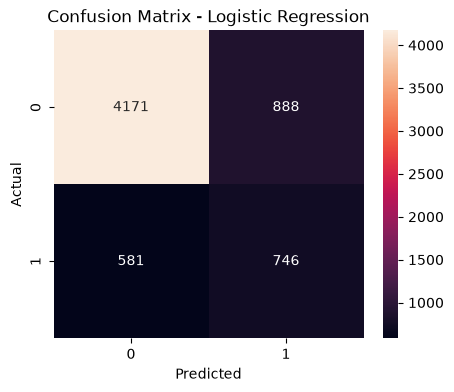

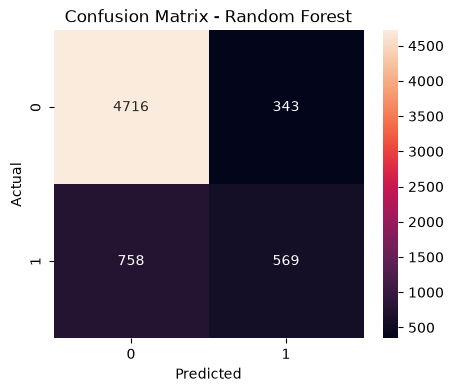

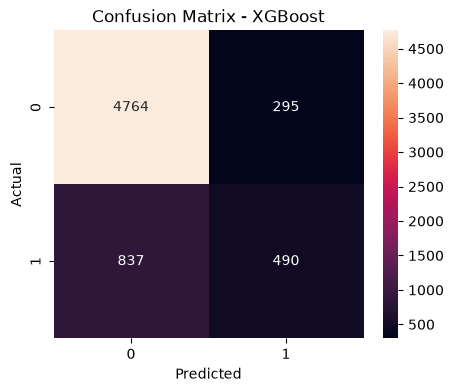

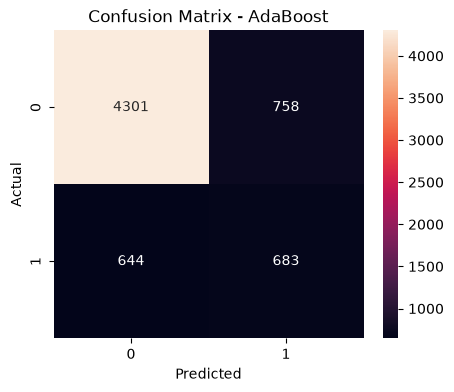

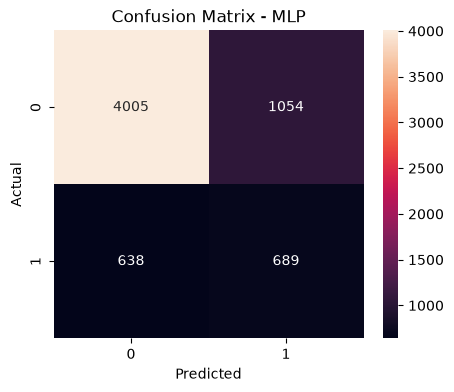

In [64]:
for name in models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

### ROC Curves

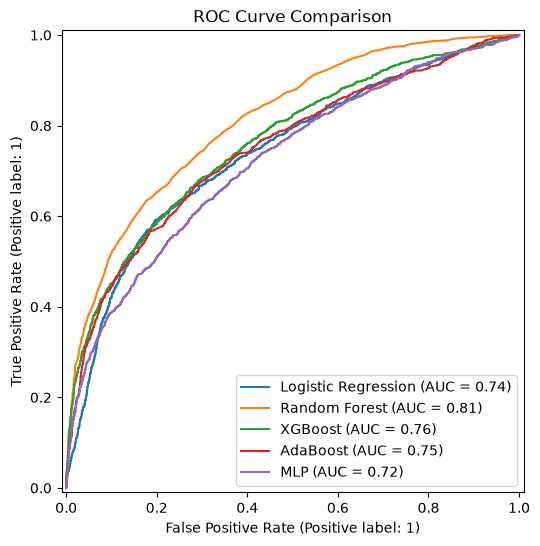

In [65]:
plt.figure(figsize=(8,6))

for name in models.keys():

    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")

plt.show()

### Hyperparameter Optimisation

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [67]:
grid_params = {

    "n_estimators": [100, 200],

    "max_depth": [10, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]
}

In [68]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=grid_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(
    X_train_smote,
    y_train_smote
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

### Best Parameters

In [69]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best ROC-AUC:
0.9462865078837372


### Evaluate Best Grid Model

In [70]:
best_grid_rf = grid_search.best_estimator_

grid_pred = best_grid_rf.predict(
    X_test_scaled
)

grid_prob = best_grid_rf.predict_proba(
    X_test_scaled
)[:,1]

### Final Metrics

In [71]:
print(
    classification_report(
        y_test,
        grid_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        grid_prob
    )
)

              precision    recall  f1-score   support

           0       0.86      0.93      0.90      5059
           1       0.62      0.43      0.51      1327

    accuracy                           0.83      6386
   macro avg       0.74      0.68      0.70      6386
weighted avg       0.81      0.83      0.82      6386

ROC-AUC: 0.8112028627381525


### Random Search CV

In [72]:
from sklearn.model_selection import RandomizedSearchCV
random_params = {

    "n_estimators": [100, 200, 300],

    "max_depth": [5, 10, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]
}

In [73]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_distributions=random_params,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train_smote,
    y_train_smote
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for mu

In [74]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

Best ROC-AUC:
0.9468779461783642


### Evaluate Best Random Search Model

In [75]:
best_random_rf = random_search.best_estimator_
random_pred = best_random_rf.predict(
    X_test_scaled
)
random_prob = best_random_rf.predict_proba(
    X_test_scaled
)[:,1]

In [76]:
print(
    classification_report(
        y_test,
        random_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        random_prob
    )
)

              precision    recall  f1-score   support

           0       0.86      0.93      0.90      5059
           1       0.63      0.43      0.51      1327

    accuracy                           0.83      6386
   macro avg       0.74      0.68      0.70      6386
weighted avg       0.81      0.83      0.82      6386

ROC-AUC: 0.8121439806068349


### Final Comparison Table

In [77]:
tuning_results = pd.DataFrame({

    "Method": [
        "Original Random Forest",
        "Grid Search RF",
        "Random Search RF"
    ],

    "ROC_AUC": [

        results_df[
            results_df["Model"]=="Random Forest"
        ]["ROC-AUC"].values[0],

        roc_auc_score(
            y_test,
            grid_prob
        ),

        roc_auc_score(
            y_test,
            random_prob
        )
    ]
})

tuning_results

,Method,ROC_AUC
0,Original Random Forest,0.811203
1,Grid Search RF,0.811203
2,Random Search RF,0.812144


### Feature Importance

In [78]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_grid_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,PAY_0,0.084211
25,LIMIT_BAL_LOG,0.051046
27,RISK_RATING,0.049893
1,LIMIT_BAL,0.048493
0,ID,0.046432
26,CITY,0.042315
5,AGE,0.041936
19,PAY_AMT2,0.040502
18,PAY_AMT1,0.039817
24,BILL_AMT_SUM,0.037159


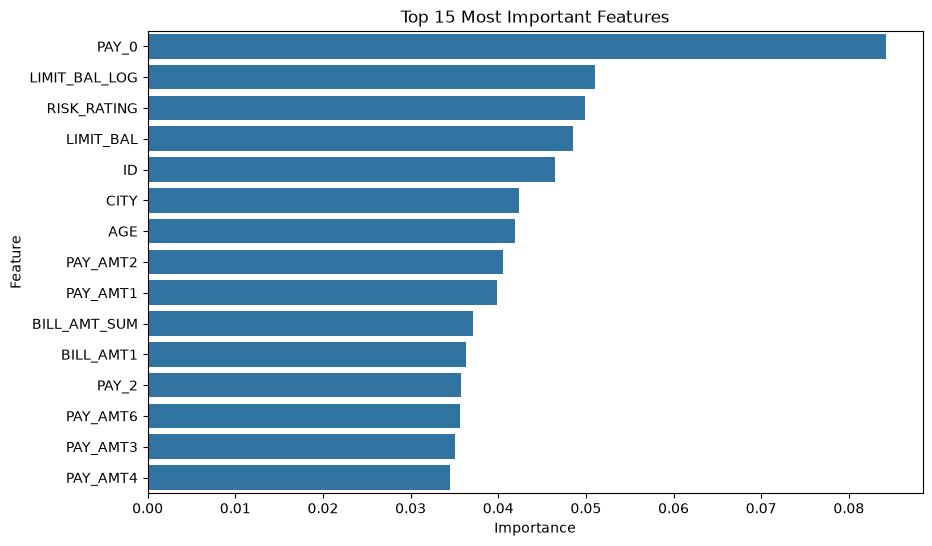

In [79]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Most Important Features"
)

plt.show()